<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/13_priority_enhancements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 13 Priority Enhancement Experiments

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook tests four targeted enhancements against the baseline Random Forest priority classifier from Notebook 12: class weighting, TF-IDF weighting, n-grams, and temporal features derived from `date_received`. Each is tested individually, then combined where beneficial.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## Importing the processed data

In [3]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_prio_train = np.load(f'{processed_dir}/y_prio_train.npy', allow_pickle=True)
y_prio_test = np.load(f'{processed_dir}/y_prio_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Setting up a results tracker for this notebook

We keep a separate results file for enhancement experiments, so the original four-model comparison stays untouched.

In [5]:
enhancement_results = []

def evaluate_and_track(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    high_recall = classification_report(y_true, y_pred, output_dict=True)['HIGH']['recall']

    enhancement_results.append({
        'experiment': name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'high_recall': high_recall
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f} | HIGH recall: {high_recall:.4f}")
    print(classification_report(y_true, y_pred))

## Experiment 1: Baseline (for reference)

Reproducing the Notebook 12 baseline result here so all comparisons sit in one place.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

baseline_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1))
])

baseline_pipeline.fit(X_train, y_prio_train)
y_pred = baseline_pipeline.predict(X_test)

evaluate_and_track('Baseline (CountVectorizer + RF)', y_prio_test, y_pred)


=== Baseline (CountVectorizer + RF) ===
Accuracy: 0.6589 | F1-macro: 0.6095 | HIGH recall: 0.3396
              precision    recall  f1-score   support

        HIGH       0.64      0.34      0.44     13017
         LOW       0.78      0.80      0.79     24049
      MEDIUM       0.51      0.71      0.59     13810

    accuracy                           0.66     50876
   macro avg       0.64      0.62      0.61     50876
weighted avg       0.67      0.66      0.65     50876



## Experiment 2: Class weighting

We tell the classifier to pay more attention to HIGH and MEDIUM, which are underrepresented relative to LOW.

In [7]:
weighted_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced'))
])

weighted_pipeline.fit(X_train, y_prio_train)
y_pred = weighted_pipeline.predict(X_test)

evaluate_and_track('Class weighting (balanced)', y_prio_test, y_pred)


=== Class weighting (balanced) ===
Accuracy: 0.6487 | F1-macro: 0.6197 | HIGH recall: 0.4516
              precision    recall  f1-score   support

        HIGH       0.55      0.45      0.50     13017
         LOW       0.84      0.72      0.78     24049
      MEDIUM       0.50      0.71      0.59     13810

    accuracy                           0.65     50876
   macro avg       0.63      0.63      0.62     50876
weighted avg       0.67      0.65      0.65     50876



## Experiment 3: TF-IDF instead of raw word counts

TF-IDF down-weights words that appear frequently across all classes (like generic Waste Management vocabulary) and up-weights words that are more distinctive to specific documents.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=1500)),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced'))
])

tfidf_pipeline.fit(X_train, y_prio_train)
y_pred = tfidf_pipeline.predict(X_test)

evaluate_and_track('TF-IDF + class weighting', y_prio_test, y_pred)


=== TF-IDF + class weighting ===
Accuracy: 0.6488 | F1-macro: 0.6198 | HIGH recall: 0.4517
              precision    recall  f1-score   support

        HIGH       0.55      0.45      0.50     13017
         LOW       0.84      0.72      0.78     24049
      MEDIUM       0.50      0.71      0.59     13810

    accuracy                           0.65     50876
   macro avg       0.63      0.63      0.62     50876
weighted avg       0.68      0.65      0.65     50876



## Experiment 4: N-grams (capturing two-word phrases)

Single words alone might miss important context. N-grams capture short phrases like "live rat" or "no water" as single features.

In [15]:
ngram_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=1500, ngram_range=(1, 2))),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced'))
])

ngram_pipeline.fit(X_train, y_prio_train)
y_pred = ngram_pipeline.predict(X_test)

evaluate_and_track('TF-IDF + n-grams + class weighting', y_prio_test, y_pred)


=== TF-IDF + n-grams + class weighting ===
Accuracy: 0.6488 | F1-macro: 0.6198 | HIGH recall: 0.4515
              precision    recall  f1-score   support

        HIGH       0.55      0.45      0.50     13017
         LOW       0.84      0.72      0.78     24049
      MEDIUM       0.50      0.71      0.59     13810

    accuracy                           0.65     50876
   macro avg       0.63      0.63      0.62     50876
weighted avg       0.68      0.65      0.65     50876



## Experiment 5: Adding temporal features from date_received

We extract day-of-week and month from the submission date  information genuinely available at the point a request is filed, unlike date_closed which would leak the answer.

In [23]:
dataset = pd.read_csv(f'{processed_dir}/swansea_cleaned.csv')

# date_received was saved in ISO format (YYYY-MM-DD) since Notebook 02 already
# converted it to a proper datetime before saving. No format string needed here.
dataset['date_received'] = pd.to_datetime(dataset['date_received'], errors='coerce')

dataset['day_of_week'] = dataset['date_received'].dt.dayofweek
dataset['month'] = dataset['date_received'].dt.month

print("Rows with valid date_received:", dataset['date_received'].notna().sum())
print("Total rows:", len(dataset))

print("\nSample of new temporal features:")
print(dataset[['request_text', 'day_of_week', 'month', 'priority']].head(10))

Rows with valid date_received: 254377
Total rows: 254377

Sample of new temporal features:
                                        request_text  day_of_week  month  \
0  Live Rat in House * Urgent* Animal Warden - Ou...            5      1   
1             Recycling Multiple Bag & Liner Request            5      1   
2             Recycling Multiple Bag & Liner Request            5      1   
3                              Domestic Bulk Request            5      1   
4                      General Rubbish/hous,building            5      1   
5                Recycling Green Week non collection            5      1   
6                Recycling Green Week non collection            5      1   
7                              Domestic Bulk Request            5      1   
8                 Recycling Pink Week non collection            5      1   
9                Recycling Green Week non collection            5      1   

  priority  
0     HIGH  
1      LOW  
2      LOW  
3      LOW  
4   MED

## Rebuilding train/test splits with temporal features included

We need to redo the split here since day_of_week and month must align with the same rows as X_train/X_test.

In [24]:
from sklearn.model_selection import train_test_split

dataset_clean = dataset.dropna(subset=['priority', 'day_of_week', 'month'])

X_text = dataset_clean['request_text'].values
X_day = dataset_clean['day_of_week'].values
X_month = dataset_clean['month'].values
y = dataset_clean['priority'].values

X_text_train, X_text_test, X_day_train, X_day_test, X_month_train, X_month_test, y_train, y_test = train_test_split(
    X_text, X_day, X_month, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("New training set size:", len(X_text_train))
print("New test set size:", len(X_text_test))

New training set size: 203501
New test set size: 50876


## Combining text and temporal features

Since text and numeric features need different preprocessing, we vectorise text separately then stack it with the numeric columns.

In [25]:
from scipy.sparse import hstack

tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X_text_train_vec = tfidf.fit_transform(X_text_train)
X_text_test_vec = tfidf.transform(X_text_test)

X_train_combined = hstack([X_text_train_vec, X_day_train.reshape(-1, 1), X_month_train.reshape(-1, 1)])
X_test_combined = hstack([X_text_test_vec, X_day_test.reshape(-1, 1), X_month_test.reshape(-1, 1)])

print("Combined training matrix shape:", X_train_combined.shape)
print("Combined test matrix shape:", X_test_combined.shape)

Combined training matrix shape: (203501, 1502)
Combined test matrix shape: (50876, 1502)


## Training and evaluating with combined text + temporal features

In [26]:
combined_classifier = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1, class_weight='balanced')
combined_classifier.fit(X_train_combined, y_train)
y_pred = combined_classifier.predict(X_test_combined)

evaluate_and_track('TF-IDF + n-grams + temporal features + class weighting', y_test, y_pred)


=== TF-IDF + n-grams + temporal features + class weighting ===
Accuracy: 0.6764 | F1-macro: 0.6534 | HIGH recall: 0.6250
              precision    recall  f1-score   support

        HIGH       0.57      0.62      0.60     13009
         LOW       0.82      0.75      0.78     24066
      MEDIUM       0.57      0.60      0.58     13801

    accuracy                           0.68     50876
   macro avg       0.65      0.66      0.65     50876
weighted avg       0.69      0.68      0.68     50876



## Comparing all experiments

                                          experiment  accuracy  f1_macro  \
0                    Baseline (CountVectorizer + RF)  0.658857  0.609522   
1                         Class weighting (balanced)  0.648656  0.619706   
2                           TF-IDF + class weighting  0.648773  0.619843   
3                 TF-IDF + n-grams + class weighting  0.648754  0.619791   
4  TF-IDF + n-grams + temporal features + class w...  0.676409  0.653430   

   f1_weighted  high_recall  
0     0.648884     0.339556  
1     0.653157     0.451563  
2     0.653290     0.451717  
3     0.653248     0.451487  
4     0.680179     0.624952  


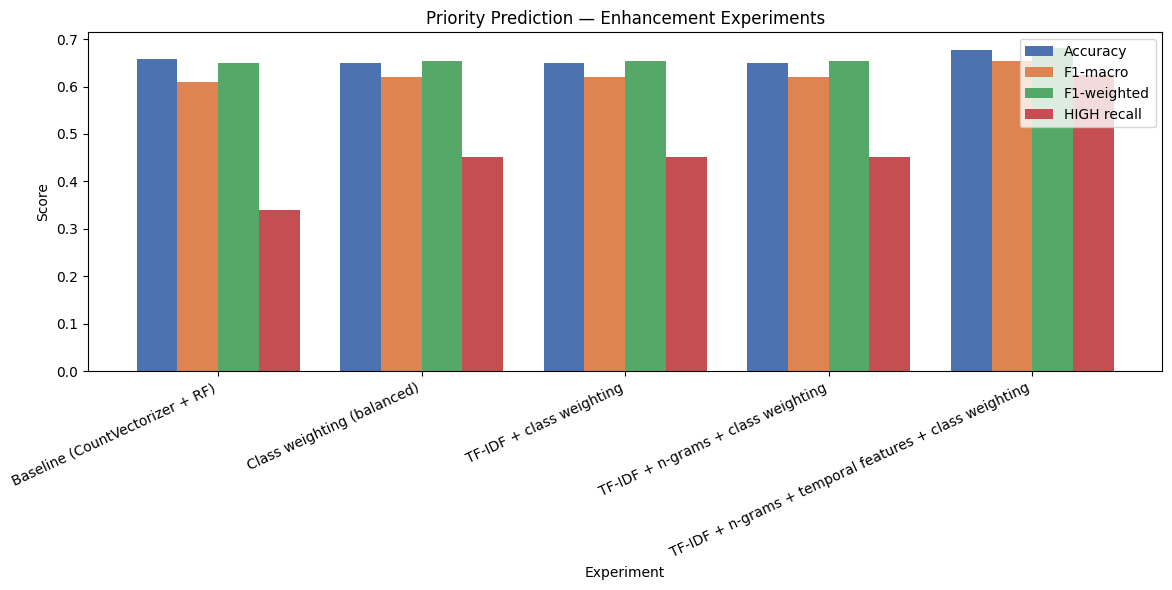

In [27]:
enhancement_df = pd.DataFrame(enhancement_results)
print(enhancement_df)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(enhancement_df))
width = 0.2

ax.bar(x - 1.5*width, enhancement_df['accuracy'], width, label='Accuracy', color='#4C72B0')
ax.bar(x - 0.5*width, enhancement_df['f1_macro'], width, label='F1-macro', color='#DD8452')
ax.bar(x + 0.5*width, enhancement_df['f1_weighted'], width, label='F1-weighted', color='#55A868')
ax.bar(x + 1.5*width, enhancement_df['high_recall'], width, label='HIGH recall', color='#C44E52')

ax.set_xlabel('Experiment')
ax.set_ylabel('Score')
ax.set_title('Priority Prediction — Enhancement Experiments')
ax.set_xticks(x)
ax.set_xticklabels(enhancement_df['experiment'], rotation=25, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Saving enhancement results

In [28]:
enhancement_path = '/content/drive/MyDrive/council-classifier/processed/priority_enhancement_results.csv'
enhancement_df.to_csv(enhancement_path, index=False)
print("Saved to:", enhancement_path)

Saved to: /content/drive/MyDrive/council-classifier/processed/priority_enhancement_results.csv
